In [1]:
import os 
from thunderboltz import ThunderBoltz # imports the main simulation object 
from thunderboltz import CrossSections 
from thunderboltz import Process 
import numpy as np
import matplotlib.pyplot as plt 
from thunderboltz import read 
import thunderboltz
print(thunderboltz.__file__)

#os.makedirs("Argon-model")

/home/emol/miniconda3/lib/python3.12/site-packages/thunderboltz/__init__.py


                   csfile  r1  r2                    rtype        B  p1  p2  \
0                  Ar.dat   0   1    ElasticFixedParticle2   0.0000   0   1   
1   Ar->Ar(3d'[3/2]1).dat   0   1  InelasticFixedParticle2  14.3760   0   1   
2   Ar->Ar(3d'[3/2]2).dat   0   1  InelasticFixedParticle2  14.3430   0   1   
3   Ar->Ar(3d'[5/2]2).dat   0   1  InelasticFixedParticle2  14.3370   0   1   
4   Ar->Ar(3d'[5/2]3).dat   0   1  InelasticFixedParticle2  14.3480   0   1   
5    Ar->Ar(3d[1/2]0).dat   0   1  InelasticFixedParticle2  14.0690   0   1   
6    Ar->Ar(3d[1/2]1).dat   0   1  InelasticFixedParticle2  14.0810   0   1   
7    Ar->Ar(3d[3/2]1).dat   0   1  InelasticFixedParticle2  14.2270   0   1   
8    Ar->Ar(3d[3/2]2).dat   0   1  InelasticFixedParticle2  14.1000   0   1   
9    Ar->Ar(3d[5/2]2).dat   0   1  InelasticFixedParticle2  14.2010   0   1   
10   Ar->Ar(3d[5/2]3).dat   0   1  InelasticFixedParticle2  14.2120   0   1   
11   Ar->Ar(3d[7/2]3).dat   0   1  InelasticFixedPar

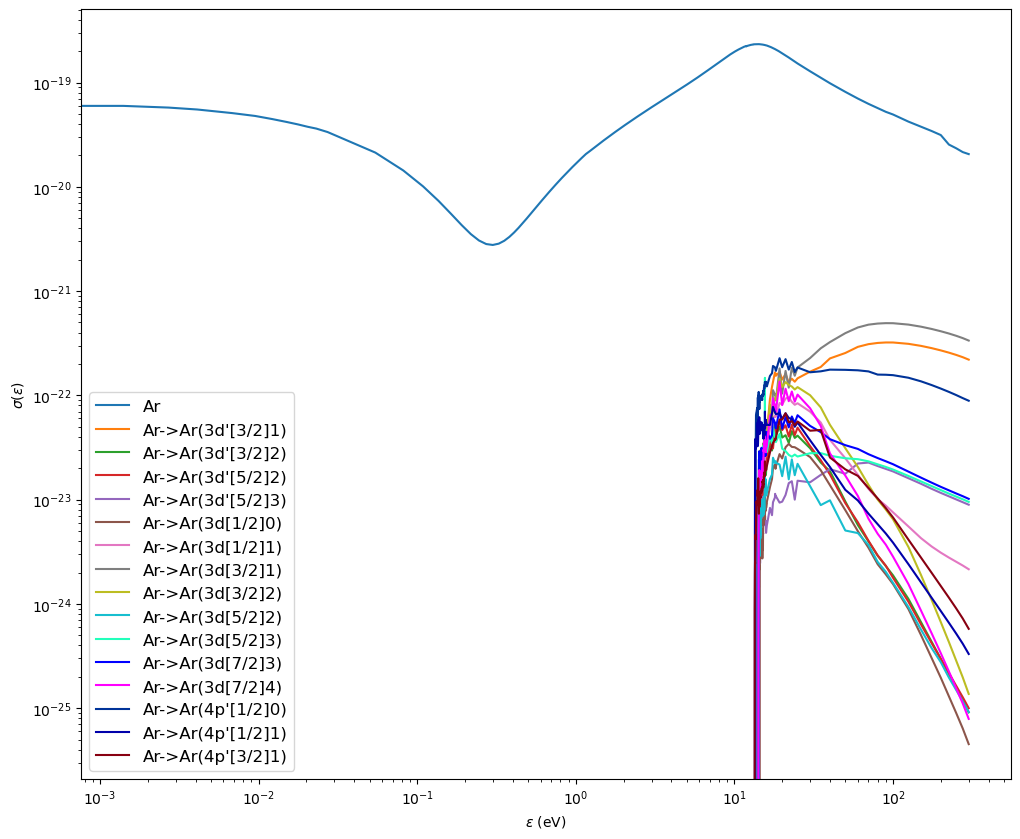

In [2]:
### Thunderboltz Run for Argon ### 

xs = CrossSections() #initalize an empty cross sections object
xs.from_LXCat("cs_LXCat_all.txt") #ICS with excitation and ionization
xs.set_fixed_background(fixed=True)

mask = xs.table.rtype == "Ionization"
xs.table.loc[mask, "rtype"] = "IonizationNoEGen"

### viewing cross sections ###
print(xs.table)
print(xs.data) # view cs associated with each process 

xs.plot_cs() # plot of cs data 
plt.show()


In [3]:
### Specify internal ThunderBoltz settings - this is for one Td ###
calc = ThunderBoltz(
    cs=xs,
    # Key simulation parameters (from TBParameters + WrapParameters)
    DT=1e-10,     # timestep (s)
    NS=30000,    # number of timesteps
    L=1e-6,       # cell length (m)
    NP=[20000, 1000],  # number of particles [electrons, neutrals]
    Ered=100,     # reduced field in Td
    eadf="default",  # isotropic angular scattering
    egen=False,   # no secondary electron generation (for simplicity)
    directory="Argon-model",) # Finally, specify a simulation directory where logging and output files will be written.
    
# now thuunderboltz has been configured and can be run. defualt all output is written into files and not stdout, but if you set this to true it can also be printed to stdout.
calc.run(std_banner=True,)

calc = read("Argon-model")

timeseries = calc.get_timeseries()
steady_state = calc.get_ss_params()

timeseries.to_csv("Argon-model/timeseries.csv", index=False)
steady_state.to_csv("Argon-model/steady.csv", index=False)

transport_params = timeseries[["MEe", "mobN", "a_n"]].copy()

/home/emol/miniconda3/lib/python3.12/site-packages/thunderboltz/tb.py:1964: SyntaxWarning: invalid escape sequence '\m'
  """Query a tree of calculations and make a simple time series plot for each


RuntimeError: Simulation directory does not exist

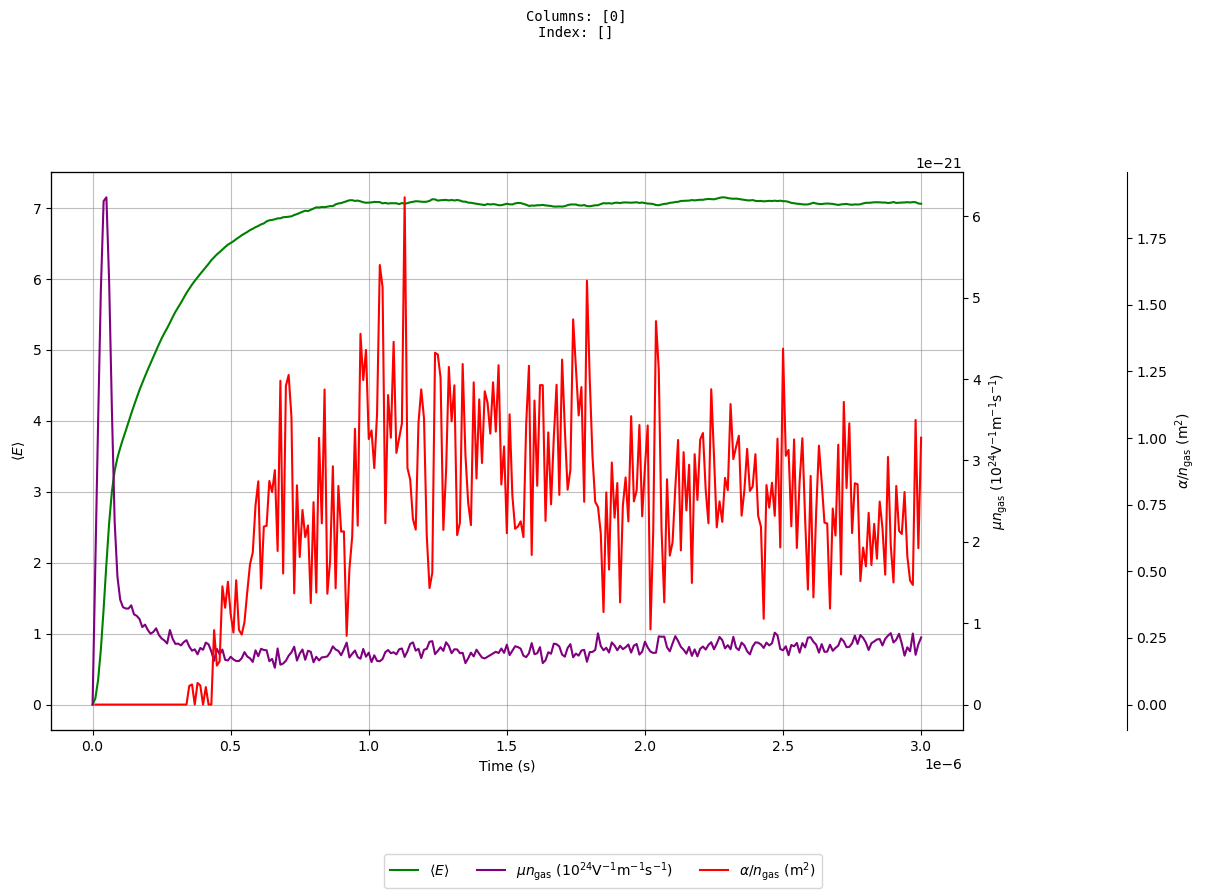

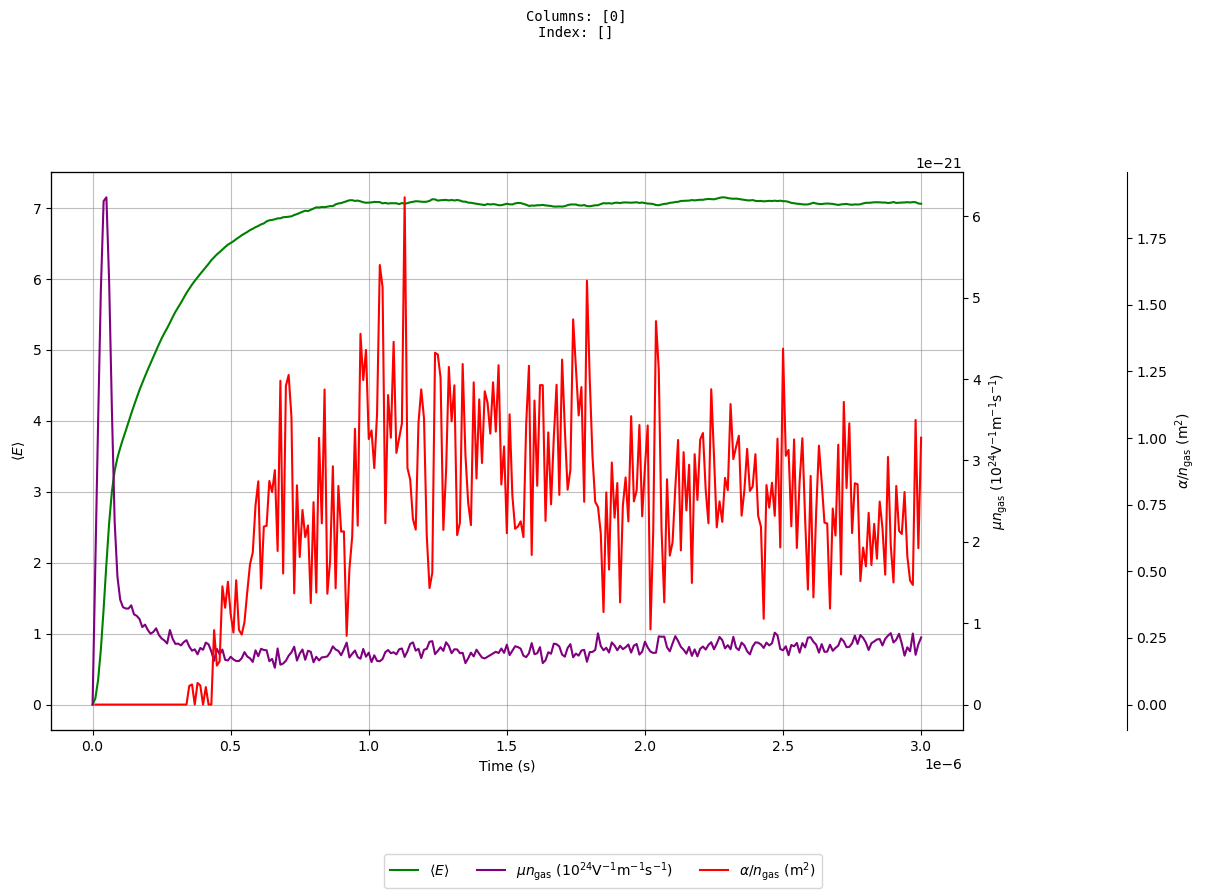

In [4]:
# plot step by stepy data for any of the output parameters available in the time series table 
# default is mean energy, mobility and townshend ionization coefficient 
calc.plot_timeseries()

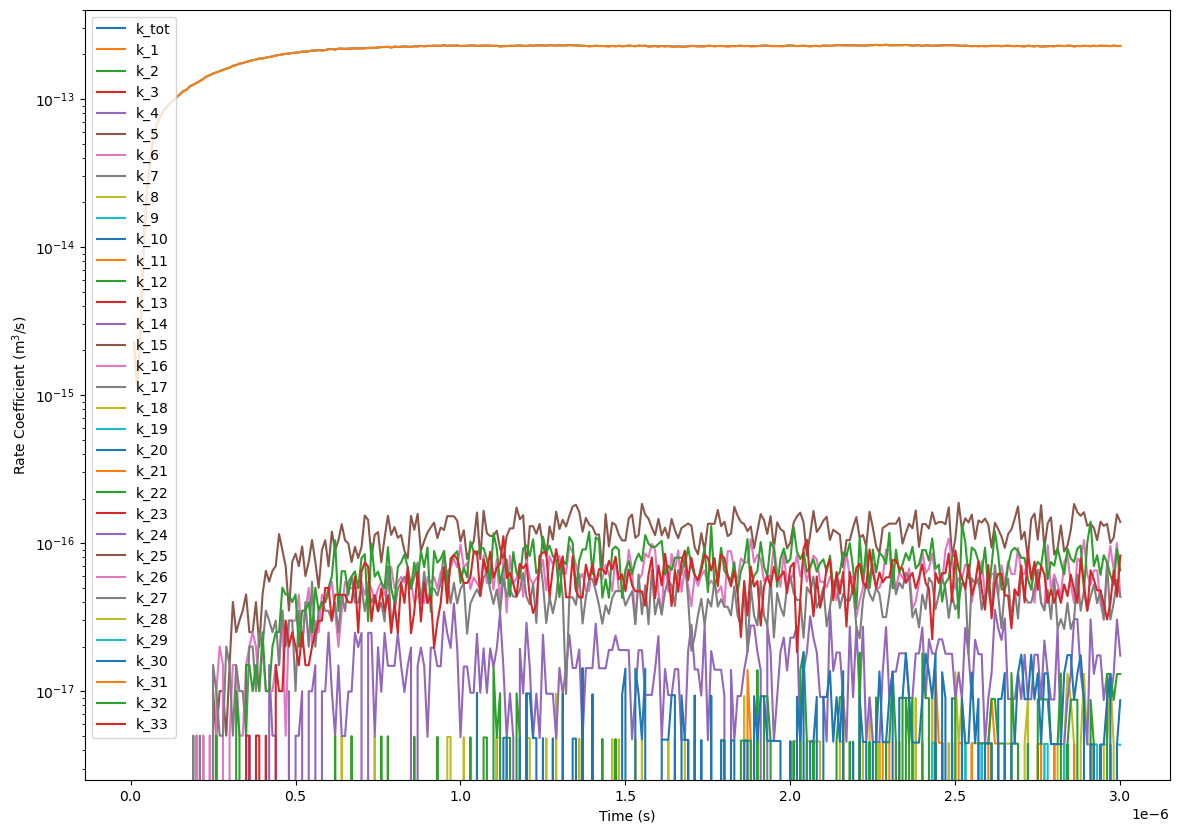

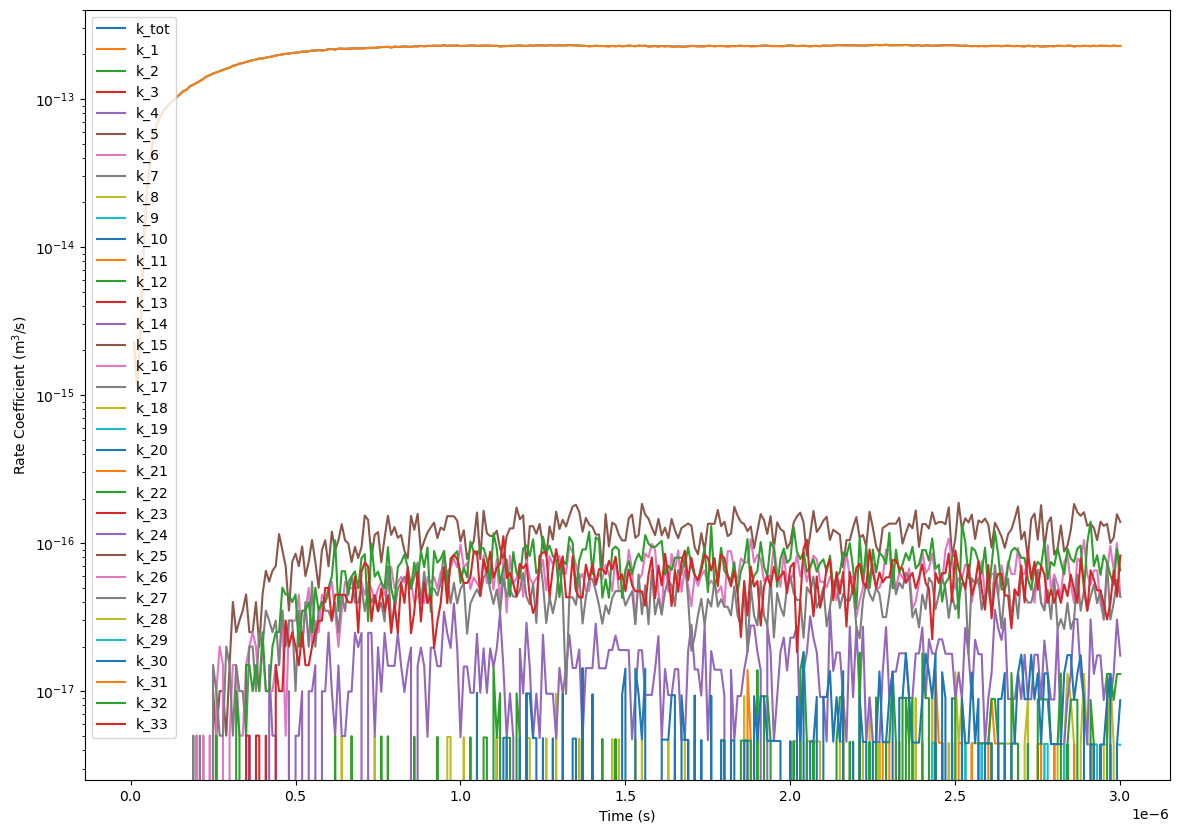

In [5]:
# plotting rate coefficients for every process 
calc.plot_rates()

                   csfile  r1  r2       rtype        B  p1  p2 model_name  \
0                  Ar.dat   0   1     Elastic   0.0000   0   1       None   
1   Ar->Ar(3d'[3/2]1).dat   0   1   Inelastic  14.3760   0   1       None   
2   Ar->Ar(3d'[3/2]2).dat   0   1   Inelastic  14.3430   0   1       None   
3   Ar->Ar(3d'[5/2]2).dat   0   1   Inelastic  14.3370   0   1       None   
4   Ar->Ar(3d'[5/2]3).dat   0   1   Inelastic  14.3480   0   1       None   
5    Ar->Ar(3d[1/2]0).dat   0   1   Inelastic  14.0690   0   1       None   
6    Ar->Ar(3d[1/2]1).dat   0   1   Inelastic  14.0810   0   1       None   
7    Ar->Ar(3d[3/2]1).dat   0   1   Inelastic  14.2270   0   1       None   
8    Ar->Ar(3d[3/2]2).dat   0   1   Inelastic  14.1000   0   1       None   
9    Ar->Ar(3d[5/2]2).dat   0   1   Inelastic  14.2010   0   1       None   
10   Ar->Ar(3d[5/2]3).dat   0   1   Inelastic  14.2120   0   1       None   
11   Ar->Ar(3d[7/2]3).dat   0   1   Inelastic  14.1650   0   1       None   

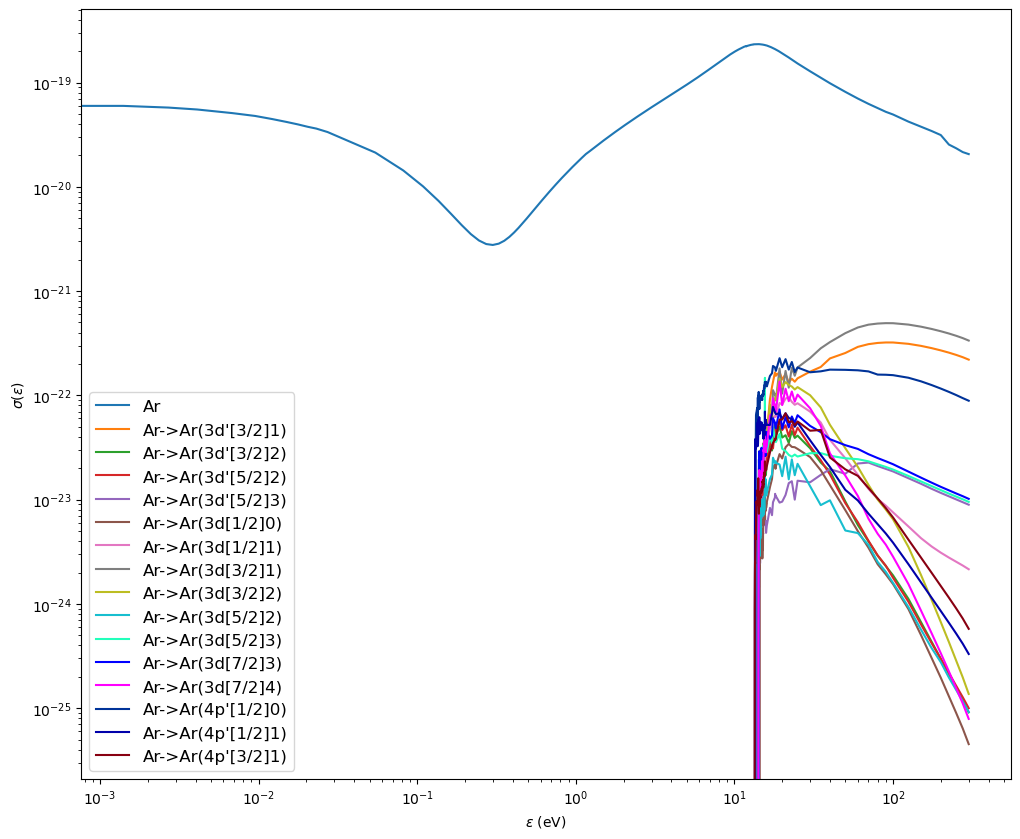

In [28]:
xs = CrossSections() #initalize an empty cross sections object
xs.from_LXCat("cs_LXCat_all.txt") #ICS with excitation and ionization

### viewing cross sections ###
print(xs.table)
print(xs.data) # view cs associated with each process 

xs.plot_cs() # plot of cs data 
plt.show()

In [81]:
### running for multiple simulations ###

import os 
from thunderboltz import ThunderBoltz
from thunderboltz import CrossSections 
from thunderboltz import Process 
import numpy as np
import matplotlib.pyplot as plt 
from thunderboltz import read 
import pandas as pd
import thunderboltz as tb

os.makedirs("Argon-Aubin-Model3-test")

calc = tb.ThunderBoltz(
    cs=xs,                
    DT=5e-7, #Time step 
    NS=80000, #Number of time steps 
    L=1e-6, #The cell size (m)
   # pct_ion=1e-3, #from helium example and needed for autostep, may need to be changed 
    NP=[30000, 3000], #Number of electrons, macroparticles
    eesd="uniform", # Use the uniform electron energy sharing ionization model.
    eadf="Ar_Aubin", # Use isotropic elastic scattering.
   # autostep=True, # (bool) Flag to calculate DT / NP / E from Ered / L /pct_ion / DE / EP_0, default is False.
    egen=False, # Do not generate secondary electrons in ionization events.
    #MEM = 10, # in GB
)

#fields = [0.001, 0.01, 0.1, 0.3, 1, 3, 10, 30, 100, 300, 1000]
#fields = [1.0, 10.0, 20, 30, 40, 50, 60, 70, 80, 90, 100, 200, 300, 400, 500, 600, 700, 800, 900, 10000]
fields = [0.01] #7, 8, 9, 10]

#loop through the field values
for field in fields:

    # Create a new directory for this reduced-field calculation 
    subdir = os.path.join("Argon_Aubin_Model3-test", f"{field}Td")
    os.makedirs(subdir)

    # Update simulation parameters
    calc.set_(Ered=field, directory=subdir)

    # Run the calculation 
    calc.run()


In [13]:
import os 
from thunderboltz import ThunderBoltz
from thunderboltz import CrossSections 
from thunderboltz import Process 
import numpy as np
import matplotlib.pyplot as plt 
from thunderboltz import read 
import pandas as pd
import thunderboltz as tb

name = "3.162Td"

calc = tb.read(f"Argon_Aubin_Model3/{name}")

timeseries = calc.get_timeseries()
steady_state = calc.get_ss_params()

# save results
timeseries.to_csv(f"Argon_Aubin_Model3/{name}/timeseries.csv", index=False)
steady_state.to_csv(f"Argon_Aubin_Model3/{name}/steady.csv", index=False)

# extract transport parameters
transport_params = timeseries[["MEe", "mobN", "a_n"]].copy()

In [5]:
pd.read_csv("Argon-model-multi/100Td/steady.csv").columns

FileNotFoundError: [Errno 2] No such file or directory: 'Argon-model-multi/100Td/steady.csv'

In [3]:
import glob
import pandas as pd
import thunderboltz as tb

steady_files = glob.glob(os.path.join("Argon_Aubin_Model3", "*Td", "steady.csv"))

merged_data = []

for file_path in steady_files:
    ### Extract E/N value from folder name (e.g. "100Td" → 100) ###
    en_value = os.path.basename(os.path.dirname(file_path)).replace("Td", "")
    df = pd.read_csv(file_path)
    
    ### Handle case where steady.csv might have multiple rows (it usually has 1) ###
    row = df.iloc[0]

    merged_data.append({
        "E/N (Td)": float(en_value),
        "μN": row.get("mobN"),
        "D_XX": row.get("D_XX"),
        "D_YY": row.get("D_YY"),
        "D_ZZ": row.get("D_ZZ"),
        "Mean Energy (eV)": row.get("MEe"),
        "α/N ": row.get("a_n"),
        "μN_std": row.get("mobN_std"), 
        "Mean Energy std": row.get("MEe_std"), 
        "DLN std": row.get("D_ZZ_std"),
        "n_gas": row.get("n_gas"), 
        #"DTN std": row.get("MEe_std"), 
        
    })
    
### Combine all runs and sort by E/N ###
merged_df = pd.DataFrame(merged_data).sort_values("E/N (Td)").reset_index(drop=True)

### Save the combined file ### 
output_path = os.path.join("Argon_Aubin_Model3", "Argon_steady_all.csv")
merged_df.to_csv(output_path, index=False)
\
display(merged_df)

,E/N (Td),μN,D_XX,D_YY,D_ZZ,Mean Energy (eV),α/N,μN_std,Mean Energy std,DLN std,n_gas
0,0.01,8.296361e+25,8918.770546,8766.288791,-2046.682688,0.300911,0.000000e+00,6.483553e+25,0.001287,18786.539405,3.000000e+21
1,0.10,1.459117e+25,5504.300756,2803.837144,-1388.012151,0.750860,0.000000e+00,1.063453e+25,0.002021,10344.115793,3.000000e+21
2,1.00,6.354657e+24,6155.842147,-3736.360922,1000.375575,3.144337,0.000000e+00,4.737102e+24,0.022660,217369.573236,2.000000e+21
3,5.00,9.094796e+23,17.726741,24.143599,18.506935,4.672757,0.000000e+00,6.620865e+23,0.016485,437.432486,1.000000e+23
4,10.00,9.500989e+23,2114.761238,1893.390880,911.853572,5.204446,1.263053e-25,3.907974e+23,0.011650,1156.767207,3.000000e+21
5,20.00,9.027047e+23,2040.099793,1637.056966,1167.653729,5.462848,9.872108e-25,2.266962e+23,0.014606,1414.063380,3.000000e+21
6,30.00,8.589165e+23,1864.248794,1704.834531,1047.277161,5.688700,1.259848e-23,1.444231e+23,0.017045,1392.600482,3.000000e+21
7,40.00,8.248632e+23,1688.061140,2052.592493,1124.429161,5.885795,5.772942e-23,1.206577e+23,0.018269,1416.731057,3.000000e+21
8,50.00,8.294742e+23,1837.897935,1780.128535,1158.328837,6.073954,1.310269e-22,8.123209e+22,0.015772,842.908394,3.000000e+21
9,60.00,8.266039e+23,2085.990430,1775.459653,1151.114662,6.241552,2.514638e-22,8.431251e+22,0.016432,651.299587,3.000000e+21


In [ ]:
df = pd.read_csv("Argon-model1-multitest/Argon_steady_all.csv")

plt.figure(figsize=(7,5))
plt.plot(df["E/N (Td)"], df["μN (m²/V·s·N)"], marker="o", lw=1.8, label="test")
plt.xscale("log")
plt.yscale("log")
# Axis labels and title
plt.xlabel("$E/N$  (Td)", fontsize=12)
plt.ylabel("$\\mu N$  (m² V⁻¹ s⁻¹ N)", fontsize=12)
plt.title("Electron Reduced Mobility in Argon", fontsize=13)

# Grid and legend
plt.legend()
plt.tight_layout()
plt.show()


                   csfile  r1  r2       rtype        B  p1  p2 model_name  \
0                  Ar.dat   0   1     Elastic   0.0000   0   1       None   
1   Ar->Ar(3d'[3/2]1).dat   0   1   Inelastic  14.3760   0   1       None   
2   Ar->Ar(3d'[3/2]2).dat   0   1   Inelastic  14.3430   0   1       None   
3   Ar->Ar(3d'[5/2]2).dat   0   1   Inelastic  14.3370   0   1       None   
4   Ar->Ar(3d'[5/2]3).dat   0   1   Inelastic  14.3480   0   1       None   
5    Ar->Ar(3d[1/2]0).dat   0   1   Inelastic  14.0690   0   1       None   
6    Ar->Ar(3d[1/2]1).dat   0   1   Inelastic  14.0810   0   1       None   
7    Ar->Ar(3d[3/2]1).dat   0   1   Inelastic  14.2270   0   1       None   
8    Ar->Ar(3d[3/2]2).dat   0   1   Inelastic  14.1000   0   1       None   
9    Ar->Ar(3d[5/2]2).dat   0   1   Inelastic  14.2010   0   1       None   
10   Ar->Ar(3d[5/2]3).dat   0   1   Inelastic  14.2120   0   1       None   
11   Ar->Ar(3d[7/2]3).dat   0   1   Inelastic  14.1650   0   1       None   

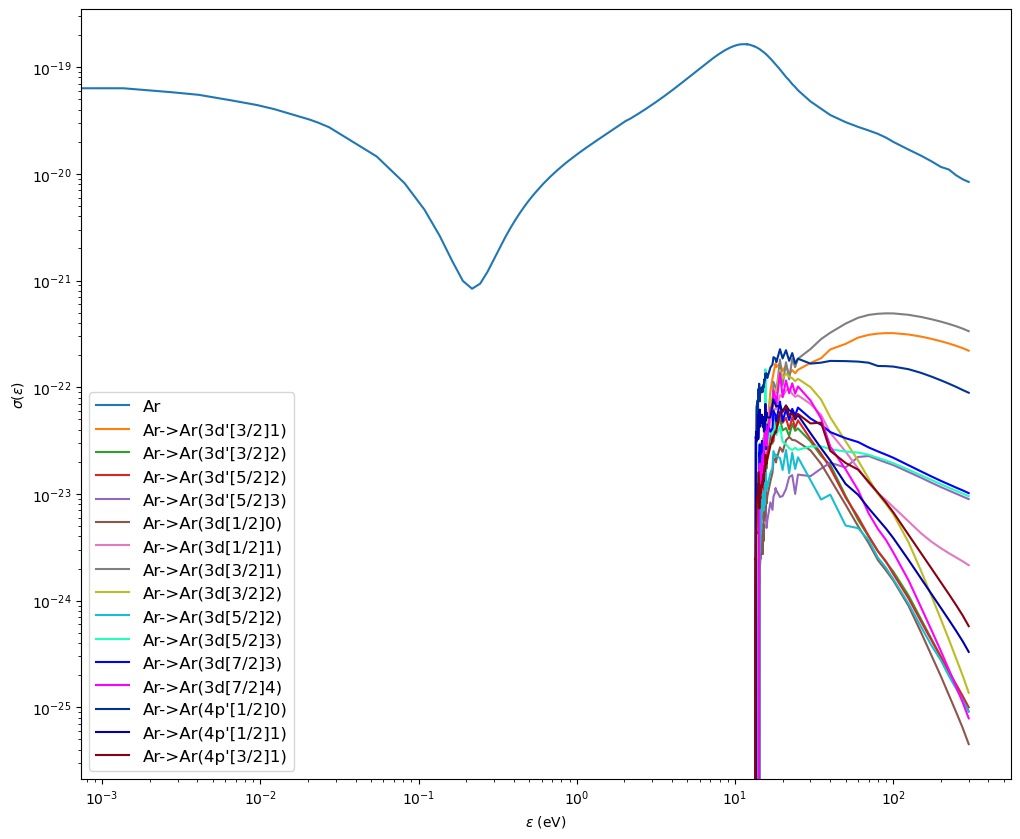

In [2]:
#momentum transfer 

import os 
from thunderboltz import ThunderBoltz # imports the main simulation object 
from thunderboltz import CrossSections 
from thunderboltz import Process 
import numpy as np
import matplotlib.pyplot as plt 
from thunderboltz import read 
import pandas as pd
import thunderboltz as tb

xs = CrossSections() #initalize an empty cross sections object
xs.from_LXCat("cs_LXCat_all_mtcs.txt") #ICS with excitation and ionization

### viewing cross sections ###
print(xs.table)
print(xs.data) # view cs associated with each process 

xs.plot_cs() # plot of cs data 
plt.show()


In [2]:
os.makedirs("Argon-model2-multi")

calc = tb.ThunderBoltz(
    cs=xs,                
    DT=2e-11,
    NS=200_000,
    L=1e-6,
    NP=[100_000, 1000],
    eadf="default",
    egen=False
)
#fields = [0.1, 0.3, 1, 3, 10, 30, 100, 300, 1000]
fields = [0.001, 0.01]

#loop through the field values
for field in fields:

    # Create a new directory for this reduced-field calculation
    subdir = os.path.join("Argon-model2-multi", f"{field}Td")
    os.makedirs(subdir)

    # Update simulation parameters
    calc.set_(Ered=field, directory=subdir)

    # Run the calculation
    calc.run()


In [23]:
name = "100.0Td"

calc = tb.read(f"Argon-model1/{name}")

timeseries = calc.get_timeseries()
steady_state = calc.get_ss_params()

# save results
timeseries.to_csv(f"Argon-model1/{name}/timeseries.csv", index=False)
steady_state.to_csv(f"Argon-model1/{name}/steady.csv", index=False)

# extract transport parameters
transport_params = timeseries[["MEe", "mobN", "a_n"]].copy()


/home/emol/miniconda3/lib/python3.12/site-packages/thunderboltz/tb.py:1962: SyntaxWarning: invalid escape sequence '\m'
  """Query a tree of calculations and make a simple time series plot for each


FileNotFoundError: [Errno 2] No such file or directory: 'Argon-model1/100.0Td'

In [4]:
import glob

steady_files = glob.glob(os.path.join("Argon-model1", "*Td", "steady.csv"))

merged_data = []

for file_path in steady_files:
    # Extract E/N value from folder name (e.g. "100Td" → 100)
    en_value = os.path.basename(os.path.dirname(file_path)).replace("Td", "")
    df = pd.read_csv(file_path)
    row = df.iloc[0]

    merged_data.append({
        "E/N (Td)": float(en_value),
        "μN": row.get("mobN"),
        "D_XX": row.get("D_XX"),
        "D_YY": row.get("D_YY"),
        "D_ZZ": row.get("D_ZZ"),
        "Mean Energy (eV)": row.get("MEe"),
        "α/N": row.get("a_n"),
        "μN_std": row.get("mobN_std"), 
        "Mean Energy std": row.get("MEe_std"), 
        "DLN std": row.get("D_ZZ_std"), 
        "n_gas": row.get("n_gas"), 
    })
    
# Combine all runs and sort by E/N
merged_df = pd.DataFrame(merged_data).sort_values("E/N (Td)").reset_index(drop=True)

# Save the combined file
output_path = os.path.join("Argon-model1", "Argon_steady_all.csv")
merged_df.to_csv(output_path, index=False)

display(merged_df)

,E/N (Td),μN,D_XX,D_YY,D_ZZ,Mean Energy (eV),α/N,μN_std,Mean Energy std,DLN std,n_gas
0,1.0,2.332981e+24,3272.571623,1572.622055,-213.787462,2.251246,0.000000e+00,1.890154e+24,0.004764,4437.307342,3.000000e+21
1,10.0,5.522362e+23,1455.832291,1181.185858,375.367763,5.115920,0.000000e+00,3.434200e+23,0.015707,1206.435780,3.000000e+21
2,20.0,5.646153e+23,1442.008801,1619.140298,600.548878,5.516969,1.501134e-25,1.952790e+23,0.016461,885.825756,3.000000e+21
3,30.0,5.527912e+23,1165.124599,1466.009972,607.919380,5.751336,3.248334e-24,1.690741e+23,0.012600,769.638727,3.000000e+21
4,40.0,5.618575e+23,1271.263266,1487.165315,719.336512,5.949871,1.719839e-23,1.350839e+23,0.016482,643.729919,3.000000e+21
5,50.0,5.764272e+23,1432.170630,1307.271137,822.869114,6.117955,4.909380e-23,1.032213e+23,0.018180,597.924619,3.000000e+21
6,60.0,5.485775e+23,1370.353033,1485.174751,723.566651,6.287926,1.293034e-22,8.405277e+22,0.018474,591.655777,3.000000e+21
7,70.0,5.446189e+23,1267.564403,1178.820686,574.367841,6.469892,2.093947e-22,7.571949e+22,0.018555,499.815793,3.000000e+21
8,80.0,5.409037e+23,1417.286647,1504.548073,747.397360,6.601906,3.248144e-22,7.129408e+22,0.020141,490.332598,3.000000e+21
9,90.0,5.094496e+23,1235.489161,1398.092122,723.904684,6.744917,4.898744e-22,6.477083e+22,0.021484,441.824305,3.000000e+21


['Dutton database', 'ETHZ (ETH Zurich, High Voltage Laboratory)', 'IST-Lisbon database', 'LAPLACE (measurements after 1975)', 'UNAM database']


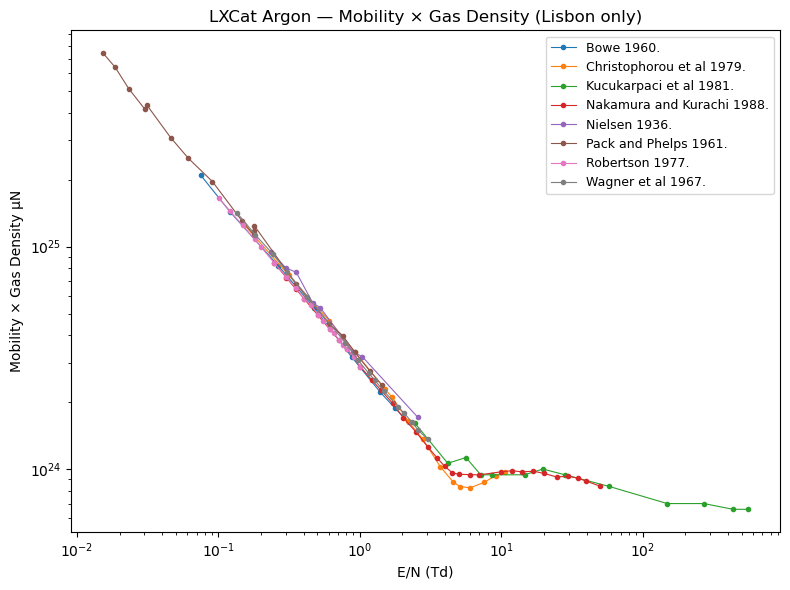

Lisbon min E/N (Td): 0.0153
Lisbon max E/N (Td): 551.29


In [5]:
### extract results on LXCat for comparison ### 
import pandas as pd
import matplotlib.pyplot as plt

def parse_lxcat_mobility(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        lines = [ln.rstrip("\n") for ln in f]

    def is_dashes(s): return s.strip().startswith("-") and set(s.strip()) == {"-"}
    def as_float(s): return float(s.replace("D","E").replace(",", "."))

    current_db = None
    i = 0
    while i < len(lines):
        line = lines[i]
        if line.startswith("DATABASE:"):
            current_db = line.split(":",1)[1].strip()
        elif line.startswith("SPECIES:") and ("e" in line and "/ Ar" in line):
            comment = ""
            j = i+1
            while j < len(lines) and not lines[j].startswith("COLUMNS:"):
                if lines[j].startswith("COMMENT:"):
                    comment = lines[j].split(":",1)[1].strip()
                j += 1
            j += 1
            if j < len(lines) and is_dashes(lines[j]):
                j += 1
                while j < len(lines) and not is_dashes(lines[j]):
                    s = lines[j].strip()
                    if s:
                        parts = s.split()
                        if len(parts) >= 2:
                            try:
                                en = as_float(parts[0])
                                muN = as_float(parts[1])
                                rows.append({
                                    "E/N (Td)": en,
                                    "μN": muN,
                                    "Database": current_db or "Unknown",
                                    "Reference": comment
                                })
                            except ValueError:
                                pass
                    j += 1
                i = j
                continue
        i += 1

    df = pd.DataFrame(rows)
    return df.sort_values(["Database","E/N (Td)"]).reset_index(drop=True)

# Parse uploaded file
path = "Mobility x gas density.txt"
lxcat_df = parse_lxcat_mobility(path)
lxcat_df = lxcat_df[lxcat_df["E/N (Td)"] >= 0.01].copy()

# Plot

# see what database strings look like
print(sorted(lxcat_df["Database"].dropna().unique().tolist()))

# keep only Lisbon entries (handles labels like "IST-Lisbon database")
lisbon = lxcat_df[lxcat_df["Database"].str.contains("lisbon", case=False, na=False)].copy()

# plot just Lisbon
plt.figure(figsize=(8,6))
for ref, g in lisbon.groupby("Reference"):
    g = g.sort_values("E/N (Td)")
    plt.loglog(g["E/N (Td)"], g["μN"], marker=".", lw=0.8, label=(ref or "IST-Lisbon"))

plt.xlabel("E/N (Td)")
plt.ylabel("Mobility × Gas Density μN")
plt.title("LXCat Argon — Mobility × Gas Density (Lisbon only)")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("Lisbon min E/N (Td):", lisbon["E/N (Td)"].min())
print("Lisbon max E/N (Td):", lisbon["E/N (Td)"].max())



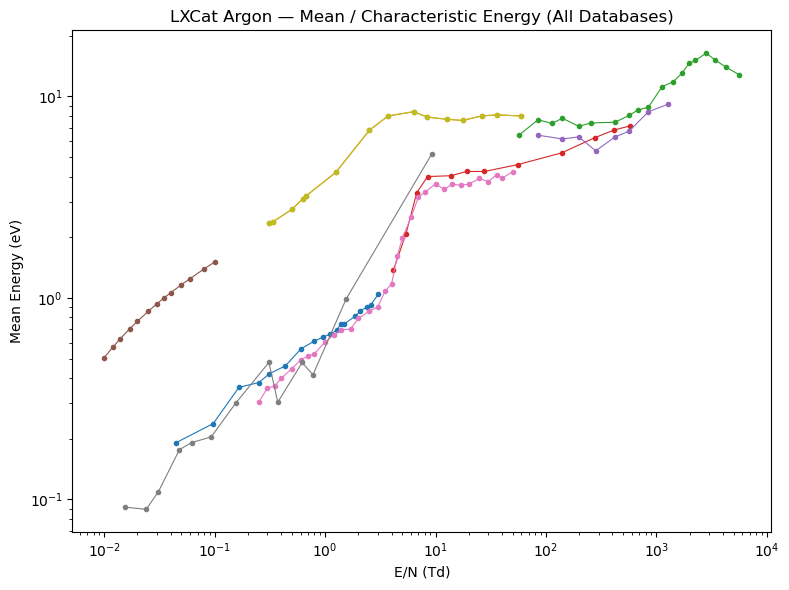

In [6]:
### extract mean energy from lxcat ### 

import pandas as pd
import matplotlib.pyplot as plt

# Path to your LXCat Energy.txt file
path = "Energy.txt"

def parse_lxcat_energy(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        lines = [ln.rstrip("\n") for ln in f]

    def is_dashes(s):
        s = s.strip()
        return s and set(s) == {"-"}

    def as_float(s):
        return float(s.replace("D", "E").replace(",", "."))

    current_db = None
    i = 0
    n = len(lines)
    while i < n:
        line = lines[i]
        # Track DATABASE headers
        if line.startswith("DATABASE:"):
            current_db = line.split(":", 1)[1].strip()
            i += 1
            continue

        # Look for SPECIES e / Ar blocks
        if line.startswith("SPECIES:"):
            sl = line.lower().replace(" ", "")
            if ("species:e/ar" in sl) or ("species:e/argon" in sl):
                process, comment, params = "", "", ""
                j = i + 1
                while j < n and not lines[j].startswith("COLUMNS:"):
                    if lines[j].startswith("PROCESS:"):
                        process = lines[j].split(":", 1)[1].strip()
                    elif lines[j].startswith("PARAM.:"):
                        params = lines[j].split(":", 1)[1].strip()
                    elif lines[j].startswith("COMMENT:"):
                        comment = lines[j].split(":", 1)[1].strip()
                    j += 1
                if j >= n or not lines[j].startswith("COLUMNS:"):
                    i += 1
                    continue
                j += 1  # dashed line
                if j < n and is_dashes(lines[j]):
                    j += 1
                    while j < n and not is_dashes(lines[j]):
                        s = lines[j].strip()
                        if s:
                            parts = s.split()
                            if len(parts) >= 2:
                                try:
                                    en = as_float(parts[0])
                                    energy = as_float(parts[1])
                                    rows.append({
                                        "E/N (Td)": en,
                                        "Mean Energy (eV)": energy,
                                        "Database": current_db or "Unknown",
                                        "Process": process,
                                        "Reference": comment,
                                        "Params": params
                                    })
                                except ValueError:
                                    pass
                        j += 1
                    i = j
                    continue
        i += 1

    if not rows:
        return pd.DataFrame(columns=["E/N (Td)", "Mean Energy (eV)", "Database", "Process", "Reference", "Params"])
    df = pd.DataFrame(rows)
    # keep only characteristic/mean energy type data if multiple processes exist
    mask = df["Process"].str.contains("energy", case=False, na=False)
    df = df[mask].copy()
    return df.sort_values(["Database", "E/N (Td)"]).reset_index(drop=True)


# --- Parse and plot all databases ---
df_energy = parse_lxcat_energy(path)
df_energy = df_energy[df_energy["E/N (Td)"] >= 0.01].copy()

plt.figure(figsize=(8,6))
for (db, ref), g in df_energy.groupby(["Database", "Reference"]):
    g = g.sort_values("E/N (Td)")
    plt.loglog(g["E/N (Td)"], g["Mean Energy (eV)"],
               marker=".", lw=0.8, label=f"{db}: {ref}" if ref else db)

plt.xlabel("E/N (Td)")
plt.ylabel("Mean Energy (eV)")
plt.title("LXCat Argon — Mean / Characteristic Energy (All Databases)")
#plt.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()


Databases found: ['Dutton database', 'ETHZ (ETH Zurich, High Voltage Laboratory)', 'LAPLACE (measurements after 1975)', 'UNAM database']


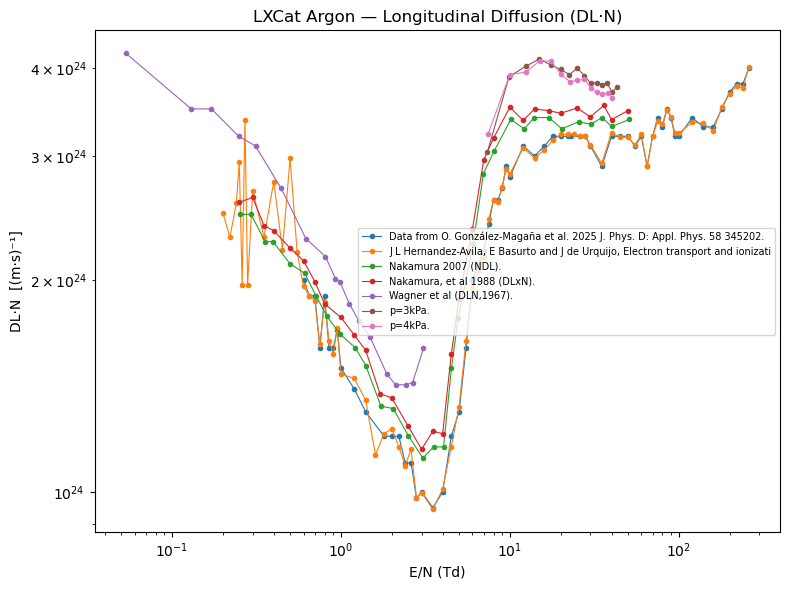

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

def parse_lxcat_diffusion(path):
    rows = []
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        lines = [ln.rstrip("\n") for ln in f]

    def is_dashes(s): 
        return s.strip().startswith("-") and set(s.strip()) == {"-"}
    def as_float(s): 
        return float(s.replace("D", "E").replace(",", "."))

    current_db = None
    current_comment = ""  # carry over top-level comment context
    i = 0
    while i < len(lines):
        line = lines[i]
        if line.startswith("DATABASE:"):
            current_db = line.split(":", 1)[1].strip()
        elif line.startswith("COMMENT:"):
            # store but do NOT reset on every new line unless inside a block
            current_comment = line.split(":", 1)[1].strip()
        elif line.startswith("SPECIES:") and ("e" in line and "/ Ar" in line):
            # capture comment lines between SPECIES and COLUMNS
            block_comment = current_comment  # inherit previous top-level comment
            j = i + 1
            while j < len(lines) and not lines[j].startswith("COLUMNS:"):
                if lines[j].startswith("COMMENT:"):
                    block_comment = lines[j].split(":", 1)[1].strip()
                j += 1
            # now read numeric block
            j += 1
            if j < len(lines) and is_dashes(lines[j]):
                j += 1
                while j < len(lines) and not is_dashes(lines[j]):
                    s = lines[j].strip()
                    if s:
                        parts = s.split()
                        if len(parts) >= 2:
                            try:
                                en = as_float(parts[0])
                                dln = as_float(parts[1])
                                rows.append({
                                    "E/N (Td)": en,
                                    "DL_N": dln,
                                    "Database": current_db or "Unknown",
                                    "Reference": block_comment or current_db or "Unknown reference"
                                })
                            except ValueError:
                                pass
                    j += 1
                i = j
                continue
        i += 1

    df = pd.DataFrame(rows)
    return df.sort_values(["Database","E/N (Td)"]).reset_index(drop=True)

# Parse uploaded file
path = "Diffusion x gas density.txt"
lxcat_df = parse_lxcat_diffusion(path)

# Show databases present
print("Databases found:", sorted(lxcat_df["Database"].unique()))

# Plot grouped by reference (publication or comment)
plt.figure(figsize=(8,6))
for ref, g in lxcat_df.groupby("Reference"):
    g = g.sort_values("E/N (Td)")
    plt.loglog(g["E/N (Td)"], g["DL_N"], marker=".", lw=0.8, label=ref[:80])  # trim long refs
plt.xlabel("E/N (Td)")
plt.ylabel("DL·N  [(m·s)⁻¹]")
plt.title("LXCat Argon — Longitudinal Diffusion (DL·N)")
plt.legend(fontsize=7)
plt.tight_layout()
plt.show()


Model 1 columns: ['E/N (Td)', 'μN', 'D_XX', 'D_YY', 'D_ZZ', 'Mean Energy (eV)', 'α/N ', 'μN_std', 'Mean Energy std', 'DLN std', 'n_gas']
Model 2 columns: ['E/N (Td)', 'μN', 'D_XX', 'D_YY', 'D_ZZ', 'Mean Energy (eV)', 'α/N', 'μN_std', 'Mean Energy std', 'DLN std', 'Ni']
      E/N (Td)       A1
0      0.01000   0.2972
1      0.03162   0.4566
2      0.10000   0.7508
3      0.21540   1.0860
4      0.46420   1.5960
5      1.00000   2.3300
6      2.15400   3.3480
7      4.00000   4.4490
8      4.64200   4.7000
9      5.04000   4.8160
10     6.35000   5.0450
11     8.00000   5.1760
12    10.00000   5.2640
13    21.54000   5.5750
14    46.42000   6.0750
15   100.00000   6.8560
16   215.40000   8.1510
17   464.20000  10.9400
18  1000.00000  18.3300
['Al-Amin et al (DT/mu).', 'Kucukarpaci et al 1981(DL/mu).', 'Lakshminarshima et al 1977 (DT/mu).', 'Milloy et al 1977 (DT/mu).', 'Nakamura et al 1988(DL/mu).', 'Pack et al 1992 (DL/mu).', 'Townsend and Bailey 1922.', 'Townsend et al 1922 (DT/mu).', 

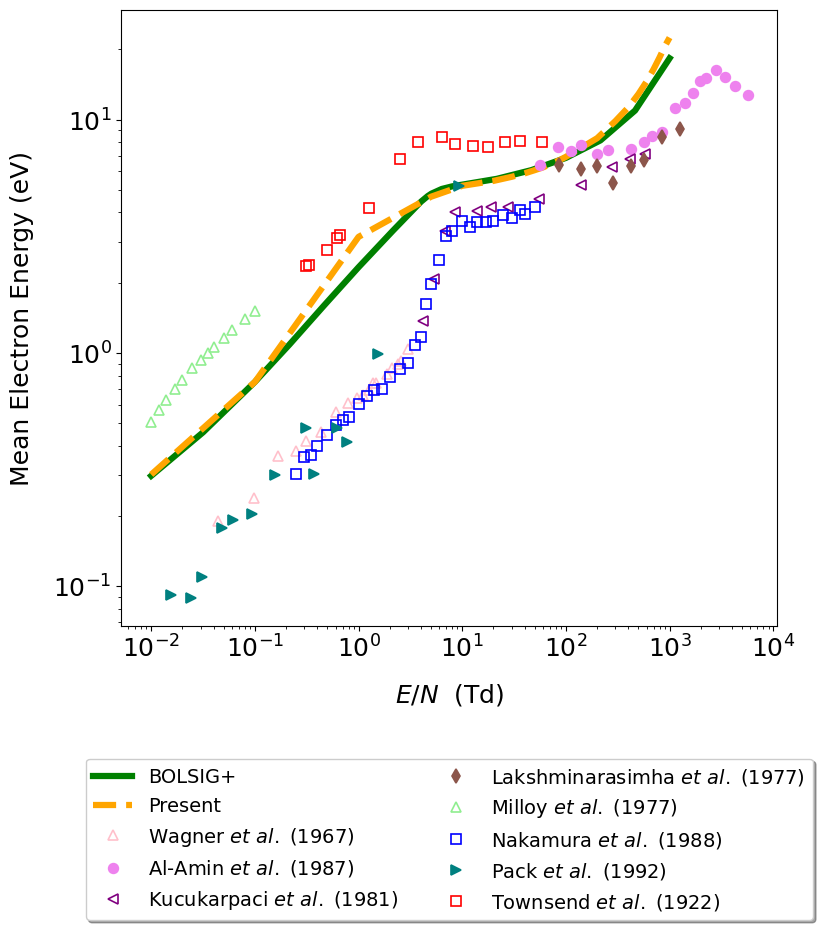

   E/N (Td)  Mean Energy (eV)       A1  Percent Error (%)
0      0.01          0.300911   0.2972           1.248710
1      0.10          0.750860   0.7508           0.008033
2      1.00          3.144337   2.3300          34.950091
3     10.00          5.204446   5.2640           1.131336
4    100.00          6.929901   6.8560           1.077906
5   1000.00         22.470550  18.3300          22.588924

========== Percent Difference vs Experimental Data ==========


--- Wagner et al 1967 (DL/mu). ---
   E/N (Td)  MeanExp  MeanModel  Percent Difference (%)
0       0.1    0.238   0.750860              215.487524
1       1.0    0.640   3.144337              391.302674
2       1.0    0.660   3.144337              376.414714

--- Al-Amin et al (DT/mu). ---
   E/N (Td)  MeanExp  MeanModel  Percent Difference (%)
0      60.0     6.40   6.241552                2.475748
1      80.0     7.66   6.593386               13.924466
2     200.0     7.11   8.326086               17.103886
3     400.0   

In [8]:

df1 = pd.read_csv("Argon_Aubin_Model3/Argon_steady_all.csv")
df2 = pd.read_csv("Argon-model2-multitest-fixed/Argon_steady_all.csv")
df3 = pd.read_csv("Argon-model1/Argon_steady_all.csv")

print("Model 1 columns:", df1.columns.tolist())
print("Model 2 columns:", df2.columns.tolist())

bolsig = pd.read_fwf(
    "bolsig_meanenergy.txt",
    names=["E/N (Td)", "A1"],
    comment="#"
)
print(bolsig)

plt.figure(figsize=(8,8))
plt.plot(bolsig["E/N (Td)"], bolsig["A1"], lw=4.5, linestyle="-", color="green", label="BOLSIG+")
plt.plot(df1["E/N (Td)"], df1["Mean Energy (eV)"], lw=4.5, linestyle="--", color="orange", label="Present")
#plt.errorbar(df3["E/N (Td)"], df3["Mean Energy (eV)"],yerr=df3["Mean Energy std"], marker="o", lw=1.8, label="Model 1 - Isotropic + ICS")
#plt.errorbar(df2["E/N (Td)"], df2["Mean Energy (eV)"], yerr=df2["Mean Energy std"], marker="o", lw=4, label="Model 2 - Isotropic + MTCS")

print(sorted(df_energy["Reference"].unique()))

lxcat_styles = {
    "Al-Amin et al (DT/mu).":         {"marker": "o", "filled": True, "color": "violet"},
    "Kucukarpaci et al 1981(DL/mu).": {"marker": "<", "filled": False,  "outline": "purple"},
    "Lakshminarshima et al 1977 (DT/mu).": {"marker": "d", "filled": True, "color": "C5"},
    "Milloy et al 1977 (DT/mu).":     {"marker": "^", "filled": False, "outline": "lightgreen"},
    "Nakamura et al 1988(DL/mu).":    {"marker": "s", "filled": False, "outline": "blue"},
    "Pack et al 1992 (DL/mu).":       {"marker": ">", "filled": True,  "color": "teal"},
    "Townsend and Bailey 1922.":      {"marker": "s", "filled": False, "outline": "red"},
    "Townsend et al 1922 (DT/mu).":   {"marker": "s", "filled": False, "outline": "red"},
    "Wagner et al 1967 (DL/mu).":     {"marker": "^", "filled": False, "outline": "pink"},

    # fallback
    "default":                        {"marker": "o", "filled": False, "outline": "black"},
}


legend_names = {
    "Al-Amin et al (DT/mu).": r"Al-Amin $\mathit{et\ al.}$ (1987)",
    "Kucukarpaci et al 1981(DL/mu).": r"Kucukarpaci $\mathit{et\ al.}$ (1981)",
    "Lakshminarshima et al 1977 (DT/mu).": r"Lakshminarasimha $\mathit{et\ al.}$ (1977)",
    "Milloy et al 1977 (DT/mu).": r"Milloy $\mathit{et\ al.}$ (1977)",
    "Nakamura et al 1988(DL/mu).": r"Nakamura $\mathit{et\ al.}$ (1988)",
    "Pack et al 1992 (DL/mu).": r"Pack $\mathit{et\ al.}$ (1992)",
    "Townsend and Bailey 1922.": r"Townsend \& Bailey (1922)",
    "Townsend et al 1922 (DT/mu).": r"Townsend $\mathit{et\ al.}$ (1922)",
    "Wagner et al 1967 (DL/mu).": r"Wagner $\mathit{et\ al.}$ (1967)",
}


skip_refs = {
    "Townsend and Bailey 1922.",
    # "Townsend et al 1922 (DT/mu)."   # add or remove depending on what you want
}


for (db, ref), g in df_energy.groupby(["Database", "Reference"]):
    if ref in skip_refs:
        continue  # ← skip plotting this dataset
    g = g.sort_values("E/N (Td)")

    # Look up style or use default
    style = lxcat_styles.get(ref, lxcat_styles["default"])

    marker = style["marker"]
    filled = style["filled"]
    color = style.get("color", None)
    outline = style.get("outline", None)

    if filled:
        facecolor = color if color is not None else None
        edgecolor = color if filled else outline
    else:
        facecolor = "none"
        edgecolor = outline if outline is not None else "black"


    plt.plot(g["E/N (Td)"], g["Mean Energy (eV)"],
         marker=marker,
         linestyle='none',
         markersize=7,
         markerfacecolor=facecolor,
         markeredgecolor=edgecolor,
         markeredgewidth=1.2, 
            label=ref)


plt.xscale("log")
plt.yscale("log")
# Axis labels and title
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xlabel("$E/N$  (Td)", fontsize=18, labelpad=14)
plt.ylabel("Mean Electron Energy (eV)", fontsize=18, labelpad=14)

handles, labels = plt.gca().get_legend_handles_labels()

new_labels = []
for lbl in labels:
    new_labels.append(legend_names.get(lbl, lbl))   # replace if in dictionary

plt.legend(handles, new_labels,
           fontsize=14,
           ncol=2,
           framealpha=1.0,
           fancybox=True,
           shadow=True,
           loc='upper center',
           bbox_to_anchor=(0.5, -0.20),
           frameon=True)

plt.tight_layout(pad=0.4)
plt.subplots_adjust(left=0.14, right=0.96, bottom=0.18, top=0.95)
plt.savefig("Mean_energy.pdf", bbox_inches='tight')
plt.show()

merged = pd.merge(df1, bolsig, on="E/N (Td)", how="inner")
merged["Percent Error (%)"] = 100 * abs(merged["Mean Energy (eV)"] - merged["A1"]) / merged["A1"]
print(merged[["E/N (Td)", "Mean Energy (eV)", "A1", "Percent Error (%)"]])

print("\n========== Percent Difference vs Experimental Data ==========\n")
def nearest_merge(exp_df, model_df, on="E/N (Td)", tol=1e-6):
    """
    Merge experimental and model data by nearest E/N instead of exact matches.
    tol = relative tolerance (fractional).
    """
    model_df = model_df.sort_values(on)
    exp_df = exp_df.sort_values(on)

    merged_rows = []
    for _, row in exp_df.iterrows():
        x = row[on]

        # find nearest model EN
        idx = (model_df[on] - x).abs().idxmin()
        nearest_val = model_df.loc[idx, on]

        # check tolerance (relative)
        if abs(nearest_val - x) / x <= tol:
            merged_rows.append({**row, **model_df.loc[idx]})

    return pd.DataFrame(merged_rows)


exp_errors = {}

for (db, ref), g in df_energy.groupby(["Database", "Reference"]):

    if ref in skip_refs:
        continue

    g = g.sort_values("E/N (Td)")

    # Rename columns BEFORE merge to avoid name collisions
    g_ren = g.rename(columns={"Mean Energy (eV)": "MeanExp"})
    df1_ren = df1.rename(columns={"Mean Energy (eV)": "MeanModel"})

    # Merge on E/N
    merged_exp = nearest_merge(g_ren, df1_ren, on="E/N (Td)", tol=0.10)

    # Compute percent difference
    merged_exp["Percent Difference (%)"] = (
        100 * abs(merged_exp["MeanModel"] - merged_exp["MeanExp"])
        / merged_exp["MeanExp"]
    )

    exp_errors[ref] = merged_exp

    # Print the comparison table
    print(f"\n--- {ref} ---")
    print(merged_exp[["E/N (Td)", "MeanExp", "MeanModel", "Percent Difference (%)"]])



['Bowe 1960.', 'Christophorou et al 1979.', 'Kucukarpaci et al 1981.', 'Nakamura and Kurachi 1988.', 'Nielsen 1936.', 'Pack and Phelps 1961.', 'Robertson 1977.', 'Wagner et al 1967.']


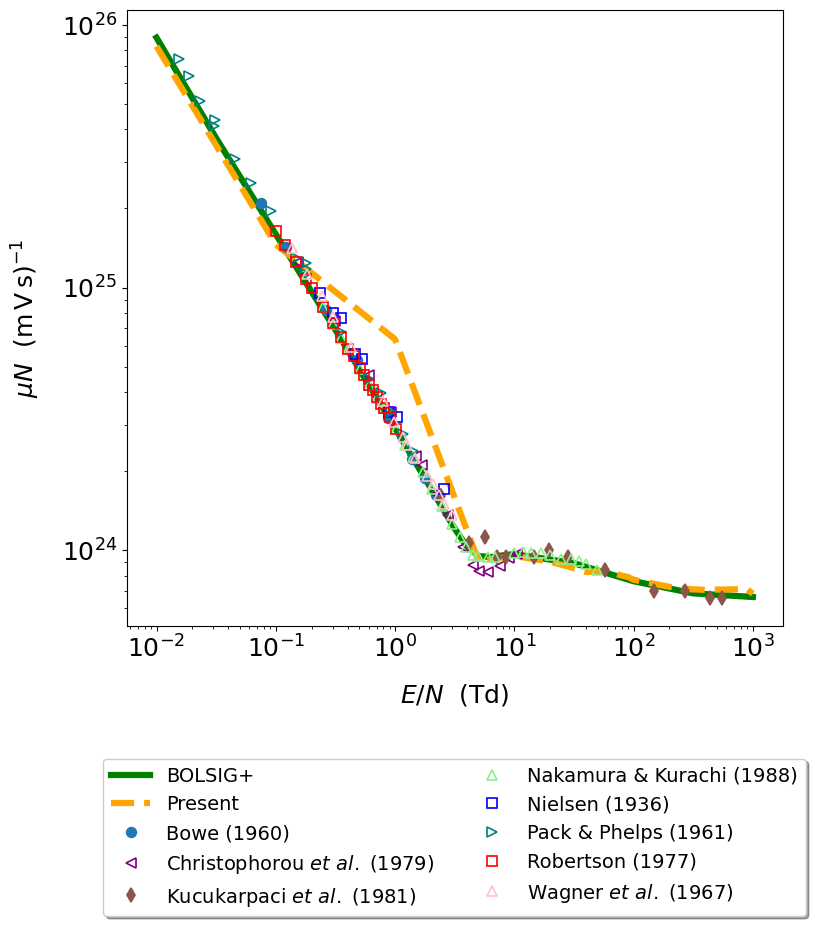


--- Present Model Percent Error (μN) ---
   E/N (Td)            μN            A2  Percent Error (%)
0      0.01  8.296361e+25  8.948000e+25           7.282512
1      0.10  1.459117e+25  1.595000e+25           8.519289
2      1.00  6.354657e+24  2.918000e+24         117.774391
3     10.00  9.500989e+23  9.655000e+23           1.595138
4    100.00  7.712570e+23  7.612000e+23           1.321208
5   1000.00  6.816654e+23  6.629000e+23           2.830809

========== Percent Difference vs Experimental Mobility Data ==========


--- Bowe 1960. ---
   E/N (Td)        μN_exp      μN_model  Percent Difference (%)
0       1.0  3.190000e+24  6.354657e+24                99.20554

--- Christophorou et al 1979. ---
   E/N (Td)        μN_exp      μN_model  Percent Difference (%)
0       1.0  3.350900e+24  6.354657e+24               89.640298
1       5.0  8.763700e+23  9.094796e+23                3.778040
2       5.0  8.341200e+23  9.094796e+23                9.034624
3      10.0  9.327200e+23  9.5009

In [9]:


df2 = pd.read_csv("Argon-model2-multitest-fixed/Argon_steady_all.csv")
df1 = pd.read_csv("Argon_Aubin_Model3/Argon_steady_all.csv")
df3 = pd.read_csv("Argon-model1/Argon_steady_all.csv")


rows = []
with open("bolsig_mobN.txt", "r") as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) >= 2:
            try:
                # force interpret as scientific notation with E
                en = float(parts[0].replace("D", "E"))
                a2 = float(parts[1].replace("D", "E"))
                rows.append([en, a2])
            except ValueError:
                continue

bolsig = pd.DataFrame(rows, columns=["E/N (Td)", "A2"])


plt.figure(figsize=(8,8))

plt.plot(bolsig["E/N (Td)"], bolsig["A2"], lw=4.5, linestyle="-", color="green", label="BOLSIG+")
         
plt.plot(df1["E/N (Td)"], df1["μN"], lw=4.5, linestyle="--", color="orange",  label="Present")
#plt.errorbar(df3["E/N (Td)"], df3["μN"],yerr=df3["μN_std"], marker="o", lw=1.8, label="Model 1 - Isotropic + ICS")
#plt.errorbar(df2["E/N (Td)"], df2[""], yerr=df2["μN_std"], marker="o", lw=1.8, label="Model 2 - Isotropic + MTCS")

print(sorted(lisbon["Reference"].unique()))

lxcat_styles = {
    "Bowe 1960.":                 {"marker": "o", "filled": True,  "outline": None},
    "Christophorou et al 1979.":  {"marker": "<", "filled": False, "outline": "purple"},
    "Kucukarpaci et al 1981.":    {"marker": "d", "filled": True, "color": "C5"},
    "Nakamura and Kurachi 1988.": {"marker": "^", "filled": False, "outline": "lightgreen"},
    "Nielsen 1936.":              {"marker": "s", "filled": False, "outline": "blue"},
    "Pack and Phelps 1961.":      {"marker": ">", "filled": False, "outline": "teal"},
    "Robertson 1977.":            {"marker": "s", "filled": False, "outline": "red"},
    "Wagner et al 1967.":         {"marker": "^", "filled": False, "outline": "pink"},
    # fallback
    "default":                    {"marker": "v", "filled": False, "outline": "black"},
}

legend_names = {
    "Bowe 1960.": r"Bowe (1960)",
    "Christophorou et al 1979.": r"Christophorou $\mathit{et\ al.}$ (1979)",
    "Kucukarpaci et al 1981.": r"Kucukarpaci $\mathit{et\ al.}$ (1981)",
    "Nakamura and Kurachi 1988.": r"Nakamura & Kurachi (1988)",
    "Nielsen 1936.": r"Nielsen (1936)",
    "Pack and Phelps 1961.": r"Pack & Phelps (1961)",
    "Robertson 1977.": r"Robertson (1977)",
    "Wagner et al 1967.": r"Wagner $\mathit{et\ al.}$ (1967)",
}

for ref, g in lisbon.groupby("Reference"):
    g = g.sort_values("E/N (Td)")

    # Look up style or use default
    style = lxcat_styles.get(ref, lxcat_styles["default"])

    marker = style["marker"]
    filled = style["filled"]
    color = style.get("color", None)
    outline = style.get("outline", None)

    if filled:
        facecolor = color if color is not None else None
        edgecolor = color if filled else outline
    else:
        facecolor = "none"
        edgecolor = outline if outline is not None else "black"


    plt.plot(g["E/N (Td)"], g["μN"],
         marker=marker,
         linestyle='none',
         markersize=7,
         markerfacecolor=facecolor,
         markeredgecolor=edgecolor,
         markeredgewidth=1.2, 
            label=ref)


plt.xscale("log")
plt.yscale("log")
# Axis labels and title
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.xlabel("$E/N$  (Td)", fontsize=18, labelpad=14)
plt.ylabel(r'$\mu N$  $\mathrm{(m\,V\,s)^{-1}}$', fontsize=18, labelpad=14)

handles, labels = plt.gca().get_legend_handles_labels()

new_labels = []
for lbl in labels:
    new_labels.append(legend_names.get(lbl, lbl))   # replace if in dictionary

plt.legend(handles, new_labels,
           fontsize=14,
           ncol=2,
           framealpha=1.0,
           fancybox=True,
           shadow=True,
           loc='upper center',
           bbox_to_anchor=(0.5, -0.20),
           frameon=True)

plt.tight_layout(pad=0.4)
plt.subplots_adjust(left=0.14, right=0.96, bottom=0.18, top=0.95)
plt.savefig("mobility_plot.pdf", bbox_inches='tight')
plt.show()

merged1 = pd.merge(df1, bolsig, on="E/N (Td)", how="inner")

# Compute percent error for PRESENT model
merged1["Percent Error (%)"] = (
    100 * abs(merged1["μN"] - merged1["A2"]) / merged1["A2"]
)

print("\n--- Present Model Percent Error (μN) ---")
print(merged1[["E/N (Td)", "μN", "A2", "Percent Error (%)"]])


def nearest_merge(exp_df, model_df, on="E/N (Td)", tol=0.15):
    """
    Merge experimental and model data using nearest E/N value,
    with a relative tolerance (tol). Default = 15%.
    """
    model_df = model_df.sort_values(on)
    exp_df = exp_df.sort_values(on)

    merged_rows = []
    for _, row in exp_df.iterrows():
        x = row[on]

        # nearest E/N value from model
        idx = (model_df[on] - x).abs().idxmin()
        nearest_val = model_df.loc[idx, on]

        # check tolerance
        if abs(nearest_val - x) / x <= tol:
            merged_rows.append({**row, **model_df.loc[idx]})

    return pd.DataFrame(merged_rows)

print("\n========== Percent Difference vs Experimental Mobility Data ==========\n")

exp_errors_mob = {}

for ref, g in lisbon.groupby("Reference"):

    # Sort experimental dataset
    g = g.sort_values("E/N (Td)")

    # Rename so columns don't collide
    g_ren = g.rename(columns={"μN": "μN_exp"})
    df1_ren = df1.rename(columns={"μN": "μN_model"})

    # Nearest-merge instead of exact merge
    merged_mob = nearest_merge(g_ren, df1_ren, on="E/N (Td)", tol=0.15)

    if merged_mob.empty:
        print(f"\n--- {ref} ---")
        print("(no matching E/N values within tolerance)\n")
        continue

    # Percent difference vs experimental μN
    merged_mob["Percent Difference (%)"] = (
        100 * abs(merged_mob["μN_model"] - merged_mob["μN_exp"])
        / merged_mob["μN_exp"]
    )

    exp_errors_mob[ref] = merged_mob

    print(f"\n--- {ref} ---")
    print(merged_mob[["E/N (Td)", "μN_exp", "μN_model", "Percent Difference (%)"]])


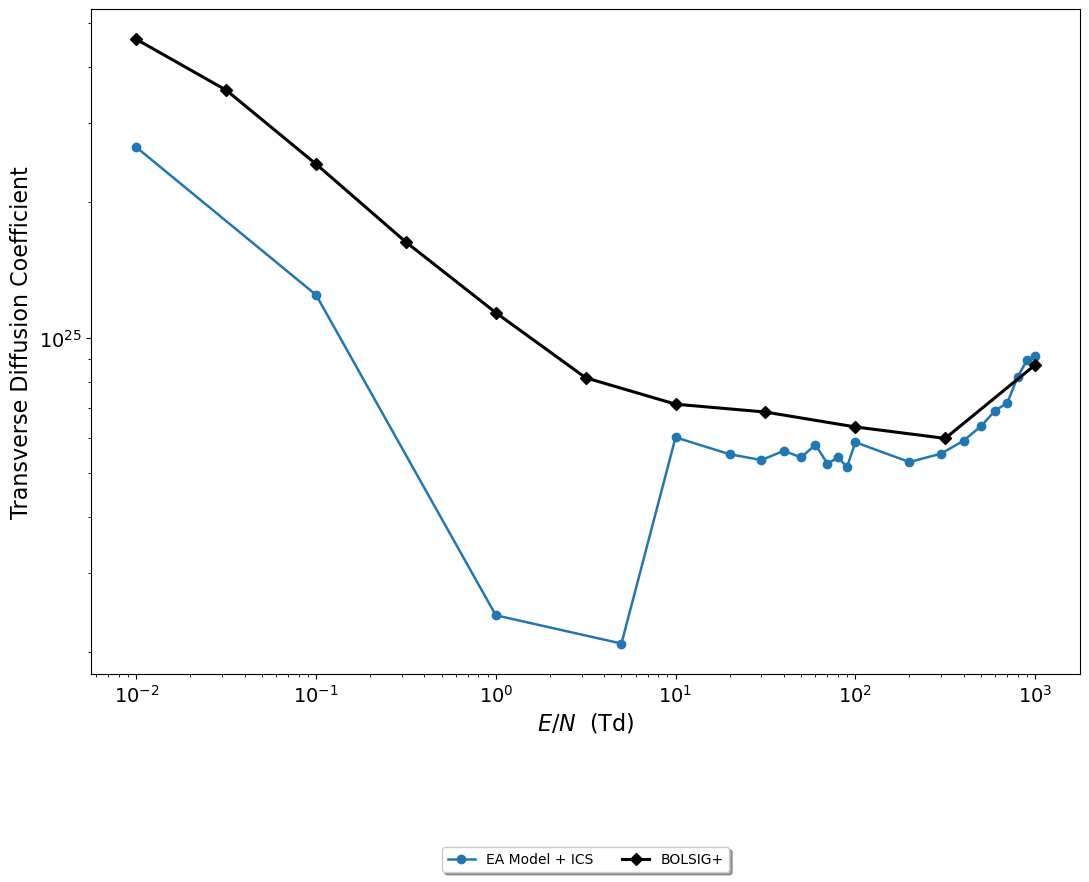

In [10]:
### Transverse Diffusion Coefficient ## 

rows = []
with open("bolsig_DTN.txt", "r") as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) >= 2:
            try:
                # force interpret as scientific notation with E
                en = float(parts[0].replace("D", "E"))
                a2 = float(parts[1].replace("D", "E"))
                rows.append([en, a2])
            except ValueError:
                continue

bolsig = pd.DataFrame(rows, columns=["E/N (Td)", "A6"])

plt.figure(figsize=(11,9))
plt.plot(df1["E/N (Td)"], 0.5 * df1["n_gas"] * (df1["D_XX"] + df1["D_YY"]), marker="o", lw=1.8, label="EA Model + ICS")
#plt.plot(df2["E/N (Td)"], 0.5 * df2["n_gas"] * (df2["D_XX"] + df2["D_YY"]), marker="o", lw=1.8, label="Model 2 - Isotropic + MTCS")
#plt.plot(df3["E/N (Td)"], 0.5 * df3["n_gas"] * (df3["D_XX"] + df3["D_YY"]), marker="o", lw=1.8, label="Model 1 - Isotropic + ICS")

plt.plot(bolsig["E/N (Td)"], bolsig["A6"],
         marker="D", lw=2.2, color="black", label="BOLSIG+")
    
plt.xscale("log")
plt.yscale("log")
plt.tick_params(axis='both', which='major', labelsize=14)
# Axis labels and title
plt.xlabel("$E/N$  (Td)", fontsize=16)
plt.ylabel("Transverse Diffusion Coefficient", fontsize=16)
#plt.title("Argon", fontsize=13)

# Grid and legend
plt.legend(
    fontsize=10,
    ncol=2,
    fancybox=True, 
    shadow=True,
    loc='upper center',           
    bbox_to_anchor=(0.5, -0.25),   
    frameon=True                  
)
plt.tight_layout()
plt.savefig("transverse_coefficient.pdf")
plt.show()



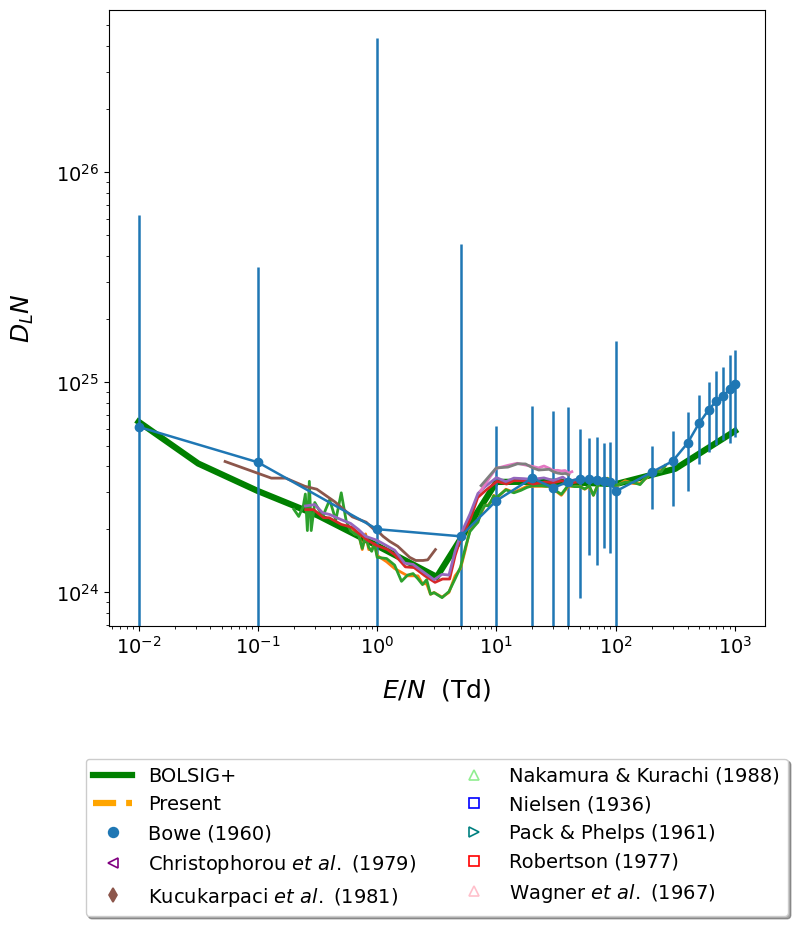

In [11]:
### Longtindual Diffusion Coefficient ### 

# Ni = neutral particle number density 

rows = []
with open("bolsig_DLN.txt", "r") as f:
    for line in f:
        parts = line.strip().split()
        if len(parts) >= 2:
            try:
                # force interpret as scientific notation with E
                en = float(parts[0].replace("D", "E"))
                a2 = float(parts[1].replace("D", "E"))
                rows.append([en, a2])
            except ValueError:
                continue

bolsig = pd.DataFrame(rows, columns=["E/N (Td)", "DLN"])

plt.figure(figsize=(8,8))

plt.plot(bolsig["E/N (Td)"], bolsig["DLN"], lw=4.5, linestyle="-", color="green", label="BOLSIG+")

plt.errorbar(df1["E/N (Td)"],df1["n_gas"] * np.abs(df1["D_ZZ"]), yerr= df1["n_gas"] * np.abs(df1["DLN std"]), marker="o", lw=1.8, label="EA Model + ICS")
#plt.plot(df1["E/N (Td)"], df1["n_gas"] * np.abs(df1["D_ZZ"]), marker="o", lw=1.8, label="EA Model + ICS")
#plt.plot(df2["E/N (Td)"], df2["n_gas"] * df2["D_ZZ"], marker="o", lw=1.8, label="Model 2 - Isotropic + MTCS")
#plt.plot(df3["E/N (Td)"], df3["n_gas"] * np.abs(df3["D_ZZ"]), marker="o", lw=1.8, label="Model 1 - Isotropic + ICS")
for ref, g in lxcat_df.groupby("Reference", dropna=False):
    g = g.sort_values("E/N (Td)")
    label = ref.strip() if isinstance(ref, str) and ref.strip() else "Unknown reference"
    plt.loglog(
        g["E/N (Td)"],
        g["DL_N"],
        lw=2.0,
        linestyle="-",
        label=label[:82]
    )



plt.xscale("log")
plt.yscale("log")
plt.tick_params(axis='both', which='major', labelsize=14)
# Axis labels and title
plt.xlabel("$E/N$  (Td)", fontsize=18, labelpad=14)
plt.ylabel(r"$D_L N$", fontsize=18, labelpad=14)
#plt.title("Argon", fontsize=13)

# Grid and legend
plt.legend(handles, new_labels,
           fontsize=14,
           ncol=2,
           framealpha=1.0,
           fancybox=True,
           shadow=True,
           loc='upper center',
           bbox_to_anchor=(0.5, -0.20),
           frameon=True)


plt.tight_layout(pad=0.4)
plt.subplots_adjust(left=0.14, right=0.96, bottom=0.18, top=0.95)
plt.savefig("longtindual_coefficient.pdf")
plt.show()